### Visualizacion de la imagen

In [4]:
pip install photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.5 MB/s eta 0:00:00


In [5]:
#librerias de cajon
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#librerias para realizar mi proceso de identificacion
from photutils.detection import DAOStarFinder, IRAFStarFinder
from photutils.detection import find_peaks
from astropy.stats import sigma_clipped_stats, mad_std
from astropy.io import fits
from scipy import ndimage

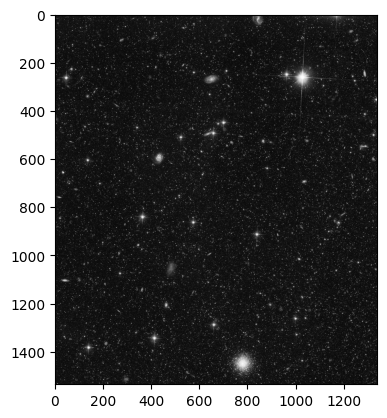

In [6]:
#cargamos la imagen
img = cv2.imread("galaxy.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap="gray")

(np.float64(-0.5), np.float64(1338.5), np.float64(1535.5), np.float64(-0.5))

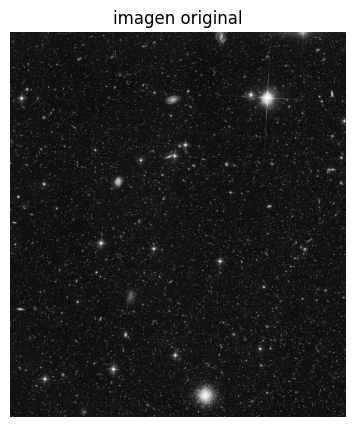

In [7]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('imagen original')
plt.axis('off')

(np.float64(-0.5), np.float64(1338.5), np.float64(1535.5), np.float64(-0.5))

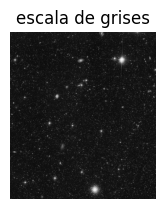

In [8]:
plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title('escala de grises')
plt.axis('off')


Text(0.5, 1.0, 'histograma de las intensidades')

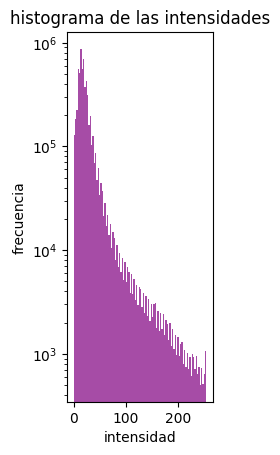

In [9]:
plt.subplot(1,3,3)
plt.hist(img.flatten(), bins = 100, alpha = 0.7, color = 'purple')
plt.yscale('log')
plt.xlabel('intensidad')
plt.ylabel('frecuencia')
plt.title('histograma de las intensidades')


### PREPROCESAMIENTO DE LA IMAGEN

In [10]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
convert = img_gris.astype(np.float32)

In [12]:
mean, median, std = sigma_clipped_stats(convert, sigma=3.0)

estadistica = {
    "maximo": convert.max(),
    "minimo": convert.min(),
    "media": mean,
    "mediana": median,
    "desviacion": std
}

print(estadistica)

{'maximo': np.float32(255.0), 'minimo': np.float32(0.0), 'media': np.float32(18.15939), 'mediana': np.float32(17.0), 'desviacion': np.float32(9.212974)}


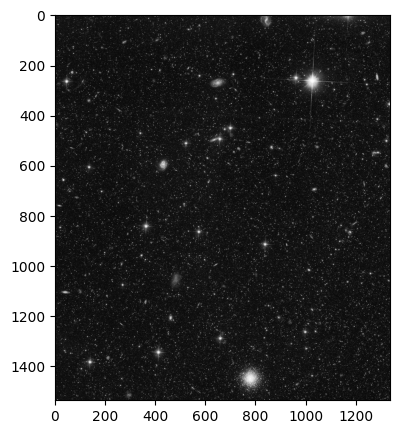

In [13]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_gris, cmap="gray")

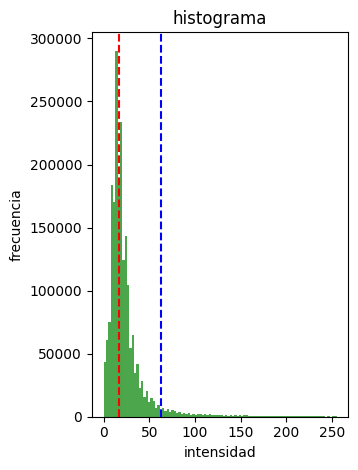

In [14]:
plt.subplot(1,2,2)
plt.hist(convert.flatten(), bins=100, alpha=0.7, color = 'green')
plt.axvline(median, color = 'red', linestyle = '--', label = f'fondo:{median:.1f}')
plt.axvline(median + 5*std, color = 'blue', linestyle = '--', label = f'5σ: {median + 5*std:.1f}')
plt.xlabel('intensidad')
plt.ylabel('frecuencia')
plt.title('histograma')
plt.tight_layout()
plt.show()

### Deteccion de estrellas con DAOStarFinder

In [15]:
#parametro para la deteccion, debemos ajustar la imagen
FWHM = 4.0

#umbral de deteccion
THRESHOLD_SIGMA = 5.0

In [16]:
#se debe de restar el fondo
fondo = convert - median

In [17]:
#se configura el detector
daofind = DAOStarFinder(
    fwhm = FWHM,
    threshold=THRESHOLD_SIGMA * std,
    sharplo = 0.2, #esto sera el filtro minimo para el sharpness
    sharphi = 1.0, #aplicamos para el filtro maximo
    roundlo = -0.5, #filtro para la redondez minimo
    roundhi = 0.5, #filtro de redondez maximo
    exclude_border = True #expluimos el borde la imagen
)

In [18]:
#mandamos a realizar una compilacion
f = daofind(fondo)

In [19]:
if f is None:
  print("no hay una deteccion de estrellas")
else:
  print(f"se detecto estrellas:{len(f)}")

se detecto estrellas:13004


In [20]:
#mandamos a llamar la imagen
print("las estrellas mostradas son:")
print(f[:5])

las estrellas mostradas son:
 id     xcentroid          ycentroid      ...    mag         daofind_mag     
--- ------------------ ------------------ ... ---------- --------------------
  1   225.143271058925 2.3443891992868577 ... -6.1928034  -0.1870727776095833
  2 248.22973569169048 2.1303634979425374 ...  -6.058115 -0.10866498449676118
  3 255.70745554239318 2.5472958328582753 ... -6.9453783  -1.1921110751651658
  4  744.0127532707303 1.9634267989554541 ... -6.6474123 -0.20529576122532883
  5 1202.3312135971619  2.097407896339218 ... -7.9011717  -1.1446046322139387


### Visualizacion de resultados

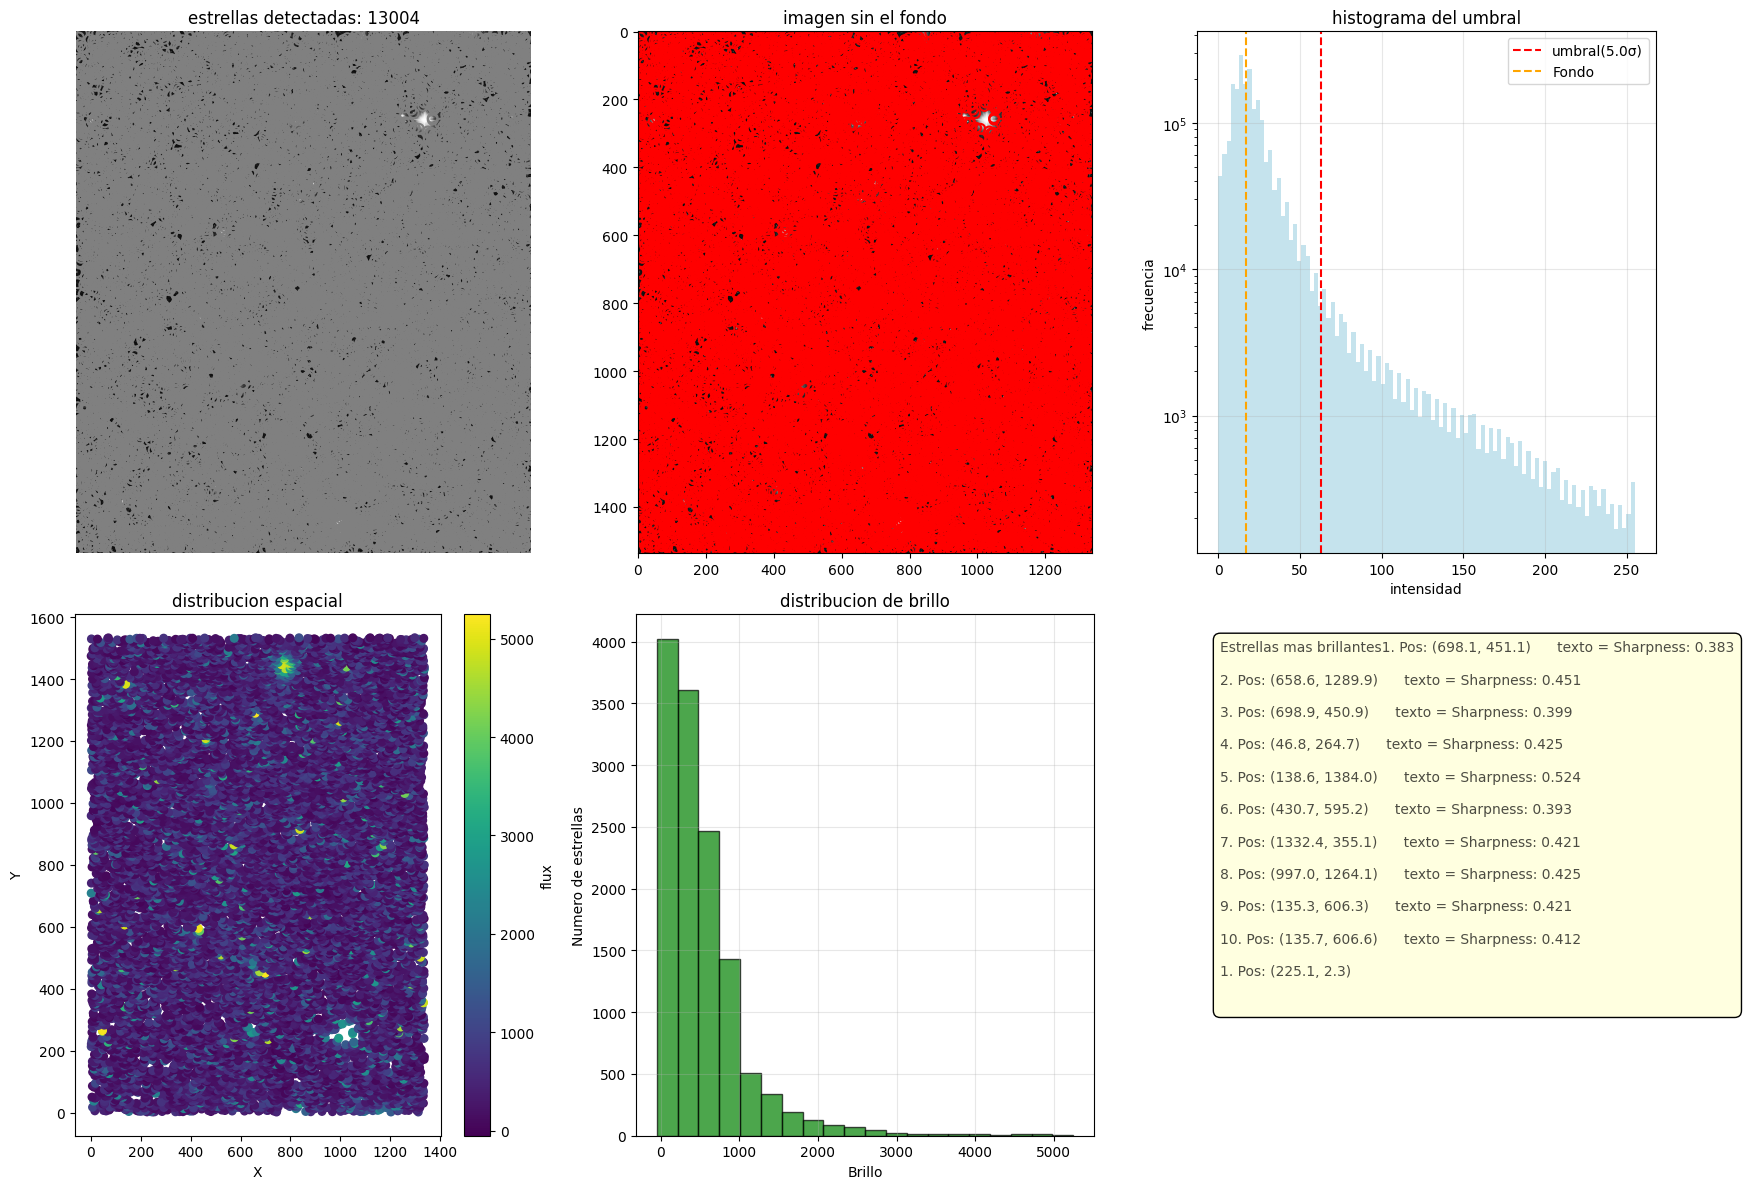

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [40]:
if f is not None and len(f) > 0:
  #visualizamos la grafica
  fig, axes = plt.subplots(2, 3, figsize = (18, 12))

  #imagen original con las estrellas marcadas xd
  axes[0,0].imshow(img_gris, cmap = "gray")
  axes[0,0].scatter(f['xcentroid'], f['ycentroid'],
                    s = 50, facecolors = 'none', edgecolors ='gray', linewidth = 1.5)
  axes[0,0].set_title(f'estrellas detectadas: {len(f)}')
  axes[0,0].axis('off')

  #ahora sin la necesidad de un fondo
  axes[0,1].imshow(fondo, cmap = 'gray')
  axes[0,1].scatter(f['xcentroid'], f['ycentroid'], s = 50, facecolors = 'none', edgecolors = 'red', linewidth = 1.5)
  axes[0,1].set_title('imagen sin el fondo')

  #Histograma con la deteccion
  intensidad = convert.flatten()
  axes[0,2].hist(intensidad, bins = 100, alpha = 0.7, color = 'lightblue')
  deteccion_umbral = median + THRESHOLD_SIGMA * std
  axes[0,2].axvline(deteccion_umbral, color = 'red', linestyle = '--', label = f'umbral({THRESHOLD_SIGMA}σ)')
  axes[0,2].axvline(median, color = 'orange', linestyle = '--', label = 'Fondo')
  axes[0,2].set_yscale('log')
  axes[0,2].set_xlabel('intensidad')
  axes[0,2].set_ylabel('frecuencia')
  axes[0,2].set_title('histograma del umbral')
  axes[0,2].legend()
  axes[0,2].grid(True, alpha = 0.3)

  #Distribucion de las estrellas
  if 'flux' in f.colnames:
    scatter = axes[1,0].scatter(f['xcentroid'], f['ycentroid'],
                                c = f['flux'], cmap = 'viridis', s=30)
    axes[1,0].set_xlabel('X')
    axes[1,0].set_ylabel('Y')
    axes[1,0].set_title('distribucion espacial')
    plt.colorbar(scatter, ax = axes[1,0], label = 'flux')

  else:
      axes[1,0].scatter(f['xcentroid'], f['ycentroid'], s = 30)
      axes[1,0].set_xlabel('X')
      axes[1,0].set_ylabel('Y')
      axes[1,0].set.title('distribucion espacial')

  #Distribucion de brillo
  if 'flux' in f.colnames:
    axes[1,1].hist(f['flux'], bins = 20, alpha = 0.7, color = 'green', edgecolor = 'black')
    axes[1,1].set_xlabel('Brillo')
    axes[1,1].set_ylabel('Numero de estrellas')
    axes[1,1].set_title('distribucion de brillo')
    axes[1,1].grid(True, alpha = 0.3)

  #Estrellas mas brillantes
  axes[1,2].axis('off')
  texto = "Estrellas mas brillantes"

  if 'flux' in f.colnames:
    #ordenamos los valores de mayor a menor
    orden = np.argsort(f['flux'])[::-1]

    for i, idx in enumerate(orden[:10]): #buscamos en un top de 10
      stars = f[idx]
      texto += f"{i+1}. Pos: ({stars['xcentroid']:.1f}, {stars['ycentroid']:.1f})\
      texto = "
      if 'sharpness' in stars.colnames:
         texto += f"Sharpness: {stars['sharpness']:.3f}\n"
      texto += "\n"

    else:
      for i in range(min(10, len(f))):
        stars = f[i]
        texto += f"{i+1}. Pos: ({stars['xcentroid']:.1f}, {stars['ycentroid']:.1f})\n\n"
        axes[1,2].text(0.05, 0.95, texto, transform = axes[1,2].transAxes, fontfamily = 'monoscape', fontsize = 10, verticalalignment = 'top',
                       bbox = dict(boxstyle = "round, pad = 0.5", facecolor = "lightyellow"), alpha = 0.7)

        plt.tight_layout()
        plt.show()

### Filtracion de las estrellas azules

In [44]:
azul = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [47]:
estrellas_azules = []
informacion_azul = []
umbral = 1.2

In [46]:
for i, estrella in enumerate(f):
  x = int(round(estrella['xcentroid']))
  y = int(round(estrella['ycentroid']))

Imagen cargada correctamente
   Dimensión color: (1536, 1339, 3)
   Dimensión gris: (1536, 1339)


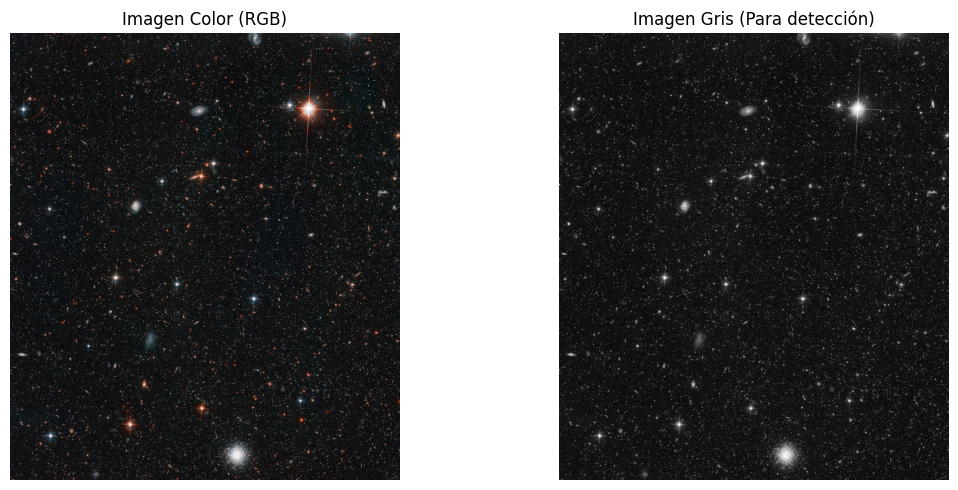

In [50]:
# CARGAR IMAGEN CON COLOR para detectar estrellas azules
img_color = cv2.imread("galaxy.jpg")  #Cargar con color (BGR)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)  #Convertir a RGB
img_gris = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)  #Para detección

print(f"Imagen cargada correctamente")
print(f"   Dimensión color: {img_rgb.shape}")
print(f"   Dimensión gris: {img_gris.shape}")

# Mostrar ambas versiones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Color (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gris, cmap='gray')
plt.title('Imagen Gris (Para detección)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [54]:
def filtrar_estrellas_azules(img_rgb, fuentes, umbral_azul=1.1):

    estrellas_azules = []
    informacion_azul = []

    print({len(fuentes)})

    for i, estrella in enumerate(fuentes):
        x = int(round(estrella['xcentroid']))
        y = int(round(estrella['ycentroid']))

        # Verificar que está dentro de la imagen
        if 0 <= x < img_rgb.shape[1] and 0 <= y < img_rgb.shape[0]:
            # Obtener color RGB - ¡IMPORTANTE: usar img_rgb!
            r, g, b = img_rgb[y, x]

            # Calcular relaciones de color
            if r > 5:  # Evitar división por cero
                relacion_b_r = b / r
                relacion_g_r = g / r

                # Criterio para estrella azul - RELAJADO
                if (relacion_b_r > umbral_azul and
                    b > g and
                    b > r and
                    b > 30):  # Mínimo de intensidad azul

                    estrellas_azules.append(estrella)
                    informacion_azul.append({
                        'id': i,
                        'x': x,
                        'y': y,
                        'r': r,
                        'g': g,
                        'b': b,
                        'relacion_b_r': relacion_b_r,
                        'relacion_g_r': relacion_g_r
                    })

    print(f"Estrellas azules detectadas: {len(estrellas_azules)}")
    return estrellas_azules, informacion_azul

# EJECUTAR FILTRO DE ESTRELLAS AZULES
if 'img_rgb' in locals() and f is not None:
    # Probar con umbral más bajo para encontrar más estrellas azules
    estrellas_azules, informacion_azul = filtrar_estrellas_azules(img_rgb, f, umbral_azul=1.1)

    # Mostrar resultados
    if len(informacion_azul) > 0:
        print(f"Se encontraron {len(estrellas_azules)} estrellas azules")
        print("detalles:")

        for info in informacion_azul:
            print(f"★ ID: {info['id']} | Pos: ({info['x']}, {info['y']})")
            print(f"  RGB: ({info['r']}, {info['g']}, {info['b']})")
            print(f"  B/R: {info['relacion_b_r']:.2f} | G/R: {info['relacion_g_r']:.2f}")

            # Clasificar por intensidad azul
            if info['b'] > 150:
                print(f"Muy azul (intensidad: {info['b']})")
            elif info['b'] > 100:
                print(f"Azul moderado (intensidad: {info['b']})")
            else:
                print(f"Azul tenue (intensidad: {info['b']})")
            print()
    else:
        print("No se encontraron estrellas azules") #habria que cambiar el umbral?????

        # Intentar con umbral más bajo
        estrellas_azules, informacion_azul = filtrar_estrellas_azules(img_rgb, f, umbral_azul=1.0)

        if len(informacion_azul) > 0:
            print(f"Con el umbral 1.0: {len(estrellas_azules)} estrellas azules")
        else:
            print("No hay estrellas azules detectables en esta imagen")
else:
    print("Ejecuta lo anterior antes wey")

{13027}
Estrellas azules detectadas: 770
Se encontraron 770 estrellas azules
detalles:
★ ID: 32 | Pos: (16, 6)
  RGB: (67, 67, 77)
  B/R: 1.15 | G/R: 1.00
Azul tenue (intensidad: 77)

★ ID: 49 | Pos: (1130, 6)
  RGB: (78, 83, 86)
  B/R: 1.10 | G/R: 1.06
Azul tenue (intensidad: 86)

★ ID: 56 | Pos: (1149, 7)
  RGB: (150, 160, 170)
  B/R: 1.13 | G/R: 1.07
Muy azul (intensidad: 170)

★ ID: 77 | Pos: (683, 10)
  RGB: (64, 68, 71)
  B/R: 1.11 | G/R: 1.06
Azul tenue (intensidad: 71)

★ ID: 99 | Pos: (822, 13)
  RGB: (145, 162, 172)
  B/R: 1.19 | G/R: 1.12
Muy azul (intensidad: 172)

★ ID: 118 | Pos: (654, 16)
  RGB: (40, 45, 48)
  B/R: 1.20 | G/R: 1.12
Azul tenue (intensidad: 48)

★ ID: 130 | Pos: (600, 17)
  RGB: (71, 76, 80)
  B/R: 1.13 | G/R: 1.07
Azul tenue (intensidad: 80)

★ ID: 137 | Pos: (829, 18)
  RGB: (120, 135, 138)
  B/R: 1.15 | G/R: 1.12
Azul moderado (intensidad: 138)

★ ID: 160 | Pos: (592, 21)
  RGB: (52, 55, 60)
  B/R: 1.15 | G/R: 1.06
Azul tenue (intensidad: 60)

★ ID: 177

🎯 Encerrando 770 estrellas azules con círculos...


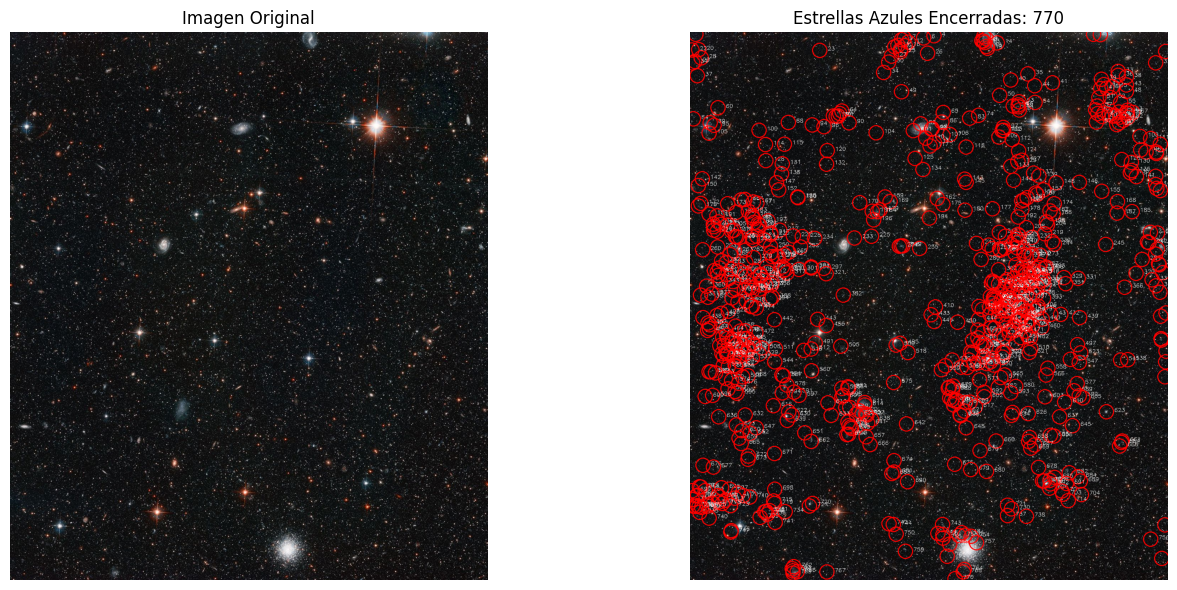

In [55]:
def encerrar_estrellas_azules_circulos(img_rgb, estrellas_azules, informacion_azul, radio=15):
    # Crear una copia para no modificar la original
    img_con_circulos = img_rgb.copy()

    print(f"🎯 Encerrando {len(estrellas_azules)} estrellas azules con círculos...")

    for i, (estrella, info) in enumerate(zip(estrellas_azules, informacion_azul)):
        x = int(round(estrella['xcentroid']))
        y = int(round(estrella['ycentroid']))

        # Dibujar círculo azul
        cv2.circle(img_con_circulos, (x, y), radio, (255, 0, 0), 2)  # Círculo azul

        # Añadir número de identificación
        cv2.putText(img_con_circulos, str(i+1), (x+radio+2, y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Mostrar resultado
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_con_circulos)
    plt.title(f'Estrellas Azules Encerradas: {len(estrellas_azules)}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return img_con_circulos

# EJECUTAR
if 'img_rgb' in locals() and 'estrellas_azules' in locals() and len(estrellas_azules) > 0:
    img_circulos = encerrar_estrellas_azules_circulos(img_rgb, estrellas_azules, informacion_azul, radio=20)